# Making Maps

If you have followed the [EM-DAT R Tutorial 1](./r_tutorial_1_basic_operations_and_plotting.ipynb) or are already familiar with [`dplyr`](https://dplyr.tidyverse.org/) and [`ggplot2`](https://ggplot2.tidyverse.org/), this second tutorial will show you basic examples on how to make maps with the EM-DAT data using the [`sf`](https://r-spatial.github.io/sf/) R package.

**Note**: This tutorial is also available on the [EM-DAT Documentation Website](https://doc.emdat.be/docs/additional-resources-and-tutorials/).

## Load Packages

Let us load the necessary packages and print their versions. For this tutorial, we used `sf` v.1.1-2, `dplyr` v.1.2.0, `jsonlite` v.2.0.0, and `ggplot2` v.4.0.2. If your package versions are different, you may have to adapt this tutorial by checking the corresponding package documentation.

In [1]:
# suppressPackageStartupMessages() hides the notes R prints when attaching
# a package; these are informational only, and their language depends on
# your system locale.
suppressPackageStartupMessages({
  library(readxl)    # read Excel files
  library(dplyr)     # data manipulation
  library(tidyr)     # data reshaping
  library(sf)        # simple features: spatial vector data
  library(jsonlite)  # parse JSON strings
  library(ggplot2)   # plotting library
})

for (p in c("readxl", "dplyr", "tidyr", "sf", "jsonlite", "ggplot2")) {
  cat(p, as.character(packageVersion(p)), "\n")
}

readxl 1.4.5 
dplyr 1.2.0 
tidyr 1.3.2 
sf 1.1.2 
jsonlite 2.0.0 
ggplot2 4.0.2 


## Creating a World Map

To create a world map, we need the EM-DAT data and a shapefile containing the country geometries.

**EM-DAT**: We download and load the EM-DAT data using `readxl`.

**Country Shapefile**: We download a country shapefile from [Natural Earth Data](https://www.naturalearthdata.com/). For a world map, we download the low resolution [1:110m Admin 0 - Countries](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/) and unzip it.

### Load and Filter EM-DAT

Let us load EM-DAT and filter it to make a global map of Earthquake disasters between 2000 and 2023. We calculate the number of unique identifiers (`DisNo.`) per country (`ISO`). We refer to the standard `ISO` column instead of the `Country` column of the [EM-DAT Public Table](https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/) to be able to make a join with the country shapefile.

In [2]:
df <- read_excel("data/260430_emdat_archive.xlsx", guess_max = 100000)  # <-- modify file name or path

earthquake_counts <- df |>
  filter(
    `Disaster Type` == "Earthquake",
    `Start Year` >= 2000,
    `Start Year` < 2024
  ) |>
  count(ISO, name = "EarthquakeCount")

earthquake_counts

ISO,EarthquakeCount
<chr>,<int>
AFG,20
ALB,4
ARG,2
ASM,1
AZE,3
BDI,1
BGD,5
BGR,2
BIH,1


### Load the Country Shapefile

We use the [`st_read`](https://r-spatial.github.io/sf/reference/st_read.html) function to load the country shapefile and parse it into an `sf` object. An `sf` object is similar to a `data.frame`, except that it has a geometry column.

We provide the `dsn` argument, which is either a file name if located in the same directory as the running script, or a relative or absolute path, if not. In our case the shapefile with the `.shp` extension is located in the `ne_110m_admin_0_countries` folder.

Since the object contains 168 attribute columns, we only keep the one we are interested in, i.e., `ISO_A3`. The `geometry` column is *sticky*: `sf` keeps it automatically through a `select`, so it does not need to be named.

**Note**: We display `sf` objects with [`print`](https://r-spatial.github.io/sf/reference/print.html) throughout this tutorial. This gives the standard `sf` summary, reporting the number of features, the geometry type, the bounding box, and the coordinate reference system, all of which are worth checking after loading spatial data.

In [3]:
gdf <- st_read(
  "data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp",  # <-- Change path if necessary
  quiet = TRUE
)

gdf <- gdf |> select(ISO_A3)
print(gdf)

Simple feature collection with 177 features and 1 field
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -90 xmax: 180 ymax: 83.64513
Geodetic CRS:  WGS 84
First 10 features:
   ISO_A3                       geometry
1     FJI MULTIPOLYGON (((180 -16.067...
2     TZA MULTIPOLYGON (((33.90371 -0...
3     ESH MULTIPOLYGON (((-8.66559 27...
4     CAN MULTIPOLYGON (((-122.84 49,...
5     USA MULTIPOLYGON (((-122.84 49,...
6     KAZ MULTIPOLYGON (((87.35997 49...
7     UZB MULTIPOLYGON (((55.96819 41...
8     PNG MULTIPOLYGON (((141.0002 -2...
9     IDN MULTIPOLYGON (((141.0002 -2...
10    ARG MULTIPOLYGON (((-68.63401 -...


**Important Notice**: Above, some geometries do not have a valid ISO code and are coded `-99` instead. Below, you will see that some ISO in EM-DAT are not matched with a geometry. Beyond this basic tutorial, we advise to carefully evaluate these correspondences and non-correspondences between ISO codes and to read the [EM-DAT Documentation about ISO codes](https://doc.emdat.be/docs/data-structure-and-content/spatial-information/).

### Join the Two Datasets

Let us merge the two datasets with a full join, using the [`full_join`](https://dplyr.tidyverse.org/reference/mutate-joins.html) function. We prefer a full join to keep the geometries of countries for which EM-DAT has no records.

**Note**: The join keys have different names in the two tables, so we pair them with [`join_by`](https://dplyr.tidyverse.org/reference/join_by.html). Starting the pipe from `gdf` matters: the result keeps the `sf` class, and stays plottable as a map.

In [4]:
earthquake_counts_with_geom <- gdf |>
  full_join(earthquake_counts, by = join_by(ISO_A3 == ISO))

print(earthquake_counts_with_geom)

Simple feature collection with 190 features and 2 fields (with 13 geometries empty)
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -90 xmax: 180 ymax: 83.64513
Geodetic CRS:  WGS 84
First 10 features:
   ISO_A3 EarthquakeCount                       geometry
1     FJI              NA MULTIPOLYGON (((180 -16.067...
2     TZA               6 MULTIPOLYGON (((33.90371 -0...
3     ESH              NA MULTIPOLYGON (((-8.66559 27...
4     CAN              NA MULTIPOLYGON (((-122.84 49,...
5     USA              10 MULTIPOLYGON (((-122.84 49,...
6     KAZ               1 MULTIPOLYGON (((87.35997 49...
7     UZB               1 MULTIPOLYGON (((55.96819 41...
8     PNG              11 MULTIPOLYGON (((141.0002 -2...
9     IDN              76 MULTIPOLYGON (((141.0002 -2...
10    ARG               2 MULTIPOLYGON (((-68.63401 -...


### Make the Map

To make the map, we use `ggplot2` together with the [`geom_sf`](https://ggplot2.tidyverse.org/reference/ggsf.html) layer, which understands the geometry column of an `sf` object and picks a sensible map projection automatically.

We map the `EarthquakeCount` column to the `fill` aesthetic, and use [`scale_fill_distiller`](https://ggplot2.tidyverse.org/reference/scale_brewer.html) to apply a sequential `Reds` colour palette. Countries without records are drawn in light grey via the `na.value` argument.

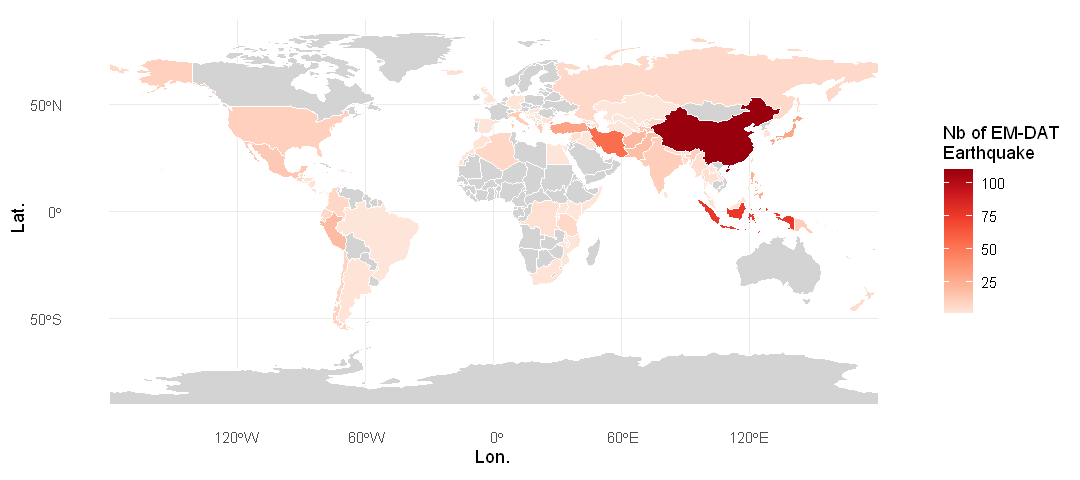

In [5]:
options(repr.plot.width = 9, repr.plot.height = 4)

ggplot(earthquake_counts_with_geom) +
  geom_sf(aes(fill = EarthquakeCount), colour = "white", linewidth = 0.1) +
  scale_fill_distiller(
    palette = "Reds",
    direction = 1,
    na.value = "lightgrey",
    name = "Nb of EM-DAT\nEarthquake"
  ) +
  labs(x = "Lon.", y = "Lat.") +
  theme_minimal()

## Creating a Map at Admin Level 1

We can create a more detailed map using the `GADM Admin Units` column in the [EM-DAT Public Table](https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/). This column contains the identifiers of administrative units of level 1 or 2 as defined by the [Database of Global Administrative Areas (GADM), version 4.1](https://gadm.org/), for countries impacted by non-biological natural hazards.

**Note**: EM-DAT also carries a legacy `Admin Units` column referring to the Global Administrative Unit Layer (GAUL). GAUL is no longer supported, and new work should use the `GADM Admin Units` column shown here.

Similarly to the country map, we need a file containing the GADM geometries. GADM publishes one geopackage per country, so we only download [the Japanese one](https://geodata.ucdavis.edu/gadm/gadm4.1/gpkg/gadm41_JPN.gpkg) (~33 MB), since this tutorial focuses on Japanese earthquake occurrence in EM-DAT.

### Load the GADM Geopackage

The file is a geopackage `.gpkg` that contains multiple layers. Let us first describe these layers with the [`st_layers`](https://r-spatial.github.io/sf/reference/st_layers.html) function.

In [6]:
print(st_layers("data/gadm41_JPN.gpkg"))

Driver: GPKG 
Available layers:
  layer_name geometry_type features fields crs_name
1  ADM_ADM_0 Multi Polygon        1      2   WGS 84
2  ADM_ADM_1 Multi Polygon       47     11   WGS 84
3  ADM_ADM_2 Multi Polygon     1811     13   WGS 84


* The `ADM_ADM_0` layer contains the country geometry.
* The `ADM_ADM_1` layer contains the 47 Japanese prefectures. This is the level we map here.
* The `ADM_ADM_2` layer contains the 1811 municipalities.

GADM ships a ready-made administrative level 1 layer, so we can load it directly. Let us keep only the identifier `GID_1` and the name `NAME_1`.

In [7]:
gadm_adm1 <- st_read("data/gadm41_JPN.gpkg", layer = "ADM_ADM_1", quiet = TRUE)

gadm_adm1 <- gadm_adm1 |> select(GID_1, NAME_1)
print(head(gadm_adm1))

Simple feature collection with 6 features and 2 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 132.0129 ymin: 32.8975 xmax: 141.6847 ymax: 41.55579
Geodetic CRS:  WGS 84
    GID_1 NAME_1                           geom
1 JPN.1_1  Aichi MULTIPOLYGON (((137.0974 34...
2 JPN.2_1  Akita MULTIPOLYGON (((140.7084 38...
3 JPN.3_1 Aomori MULTIPOLYGON (((140.9563 40...
4 JPN.4_1  Chiba MULTIPOLYGON (((139.8242 34...
5 JPN.5_1  Ehime MULTIPOLYGON (((132.5619 32...
6 JPN.6_1  Fukui MULTIPOLYGON (((135.7774 35...


### Filter EM-DAT Data

In [8]:
df_jpn <- df |>
  filter(
    ISO == "JPN",
    `Disaster Type` == "Earthquake",
    `Start Year` >= 2000,
    `Start Year` < 2024
  ) |>
  select(`DisNo.`, `GADM Admin Units`)

df_jpn

DisNo.,GADM Admin Units
<chr>,<chr>
2000-0428-JPN,NA
2019-0322-JPN,"[{""gid_1"":""JPN.15_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Ishikawa""},{""gid_1"":""JPN.24_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Miyagi""},{""gid_1"":""JPN.29_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Niigata""},{""gid_1"":""JPN.45_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Yamagata""}]"
2016-0121-JPN,"[{""gid_1"":""JPN.21_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Kumamoto""},{""gid_1"":""JPN.25_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Miyazaki""},{""gid_1"":""JPN.34_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Saga""}]"
2016-0492-JPN,NA
2011-0082-JPN,"[{""gid_1"":""JPN.10_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Gunma""},{""gid_1"":""JPN.12_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Hokkaido""},{""gid_1"":""JPN.14_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Ibaraki""},{""gid_1"":""JPN.16_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Iwate""},{""gid_1"":""JPN.19_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Kanagawa""},{""gid_1"":""JPN.24_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Miyagi""},{""gid_1"":""JPN.26_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Nagano""},{""gid_1"":""JPN.2_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Akita""},{""gid_1"":""JPN.35_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Saitama""},{""gid_1"":""JPN.39_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Tochigi""},{""gid_1"":""JPN.3_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Aomori""},{""gid_1"":""JPN.41_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Tokyo""},{""gid_1"":""JPN.45_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Yamagata""},{""gid_1"":""JPN.4_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Chiba""},{""gid_1"":""JPN.8_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Fukushima""}]"
2018-0183-JPN,"[{""gid_1"":""JPN.13_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Hyōgo""},{""gid_1"":""JPN.22_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Kyoto""},{""gid_1"":""JPN.28_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Nara""},{""gid_1"":""JPN.33_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard1"",""name_1"":""Osaka""}]"
2018-0330-JPN,"[{""gid_2"":""JPN.12.11_1"",""migration_date"":""2025-12-20"",""migration_method"":""jaccard2"",""name_2"":""Atsuma""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"":""JPN.12.123_1"",""migration_date"":""2025-12-20"",""migration_method"":""bufhaus2"",""name_2"":""Sapporo""},{""gid_2"

**Note**: Some events are not geolocated at a finer administrative level and have a missing (`NA`) value.

### Convert Admin 2 units to Admin 1 units

We create an R function, `gadm_to_admin1`, to extract the administrative level 1 identifiers from the `GADM Admin Units` column.

The `GADM Admin Units` column holds a JSON array whose entries provide either a level 1 identifier (`gid_1`) or a level 2 identifier (`gid_2`). GADM identifiers are *hierarchical strings*: the level 2 identifier `JPN.19.68_2` is nested under the level 1 identifier `JPN.19_1`. We can therefore derive the parent unit by trimming the string, with no spatial lookup required.

**Note**: The trailing `_1` or `_2` in a GADM identifier is a version suffix, not a level marker, which is why we always append `_1` when building a level 1 identifier.

In [9]:
#' Convert a GADM Admin Units JSON string to administrative level 1 identifiers.
#'
#' @param json_str A JSON string representing administrative areas, or NA.
#' @return A character vector of unique GADM level 1 (GID_1) identifiers.
gadm_to_admin1 <- function(json_str) {
  if (is.na(json_str)) {
    return(character(0))
  }
  entries <- fromJSON(json_str, simplifyVector = FALSE)
  ids <- vapply(entries, function(entry) {
    if (!is.null(entry$gid_1)) {
      entry$gid_1
    } else if (!is.null(entry$gid_2)) {
      # JPN.19.68_2 -> JPN.19_1
      sub("^([A-Za-z]{3}\\.[0-9]+)\\..*$", "\\1_1", entry$gid_2)
    } else {
      stop("Administrative code is missing from the provided data.")
    }
  }, character(1))
  unique(ids)
}

We apply the function to all elements of the `GADM Admin Units` column. Because each event may span several administrative units, the function returns a vector of varying length, which we store in a *list column* using [`lapply`](https://rdrr.io/r/base/lapply.html).

**Note**: A list column holds a whole vector in each cell, so it has no fixed width and cannot be shown as an ordinary table. Below we collapse each list into a single comma-separated string purely for display; `df_jpn` itself keeps the list column, which is what the next step needs.

In [10]:
df_jpn <- df_jpn |>
  mutate(GID_1 = lapply(`GADM Admin Units`, gadm_to_admin1))

# Collapse the list column to a string, for display only
df_jpn |>
  select(`DisNo.`, GID_1) |>
  mutate(GID_1 = sapply(GID_1, paste, collapse = ", "))

DisNo.,GID_1
<chr>,<chr>
2000-0428-JPN,
2019-0322-JPN,"JPN.15_1, JPN.24_1, JPN.29_1, JPN.45_1"
2016-0121-JPN,"JPN.21_1, JPN.25_1, JPN.34_1"
2016-0492-JPN,
2011-0082-JPN,"JPN.10_1, JPN.12_1, JPN.14_1, JPN.16_1, JPN.19_1, JPN.24_1, JPN.26_1, JPN.2_1, JPN.35_1, JPN.39_1, JPN.3_1, JPN.41_1, JPN.45_1, JPN.4_1, JPN.8_1"
2018-0183-JPN,"JPN.13_1, JPN.22_1, JPN.28_1, JPN.33_1"
2018-0330-JPN,JPN.12_1
2016-0107-JPN,JPN.21_1
2004-0532-JPN,


### Count Earthquakes per Admin 1 Units

This can be done by applying the [`unnest_longer`](https://tidyr.tidyverse.org/reference/unnest_longer.html) function on the new `GID_1` list column. The function adds one row per identifier contained in each list. Then the counting can be performed using the former `count` approach.

**Note**: Events with no administrative unit hold an empty vector and are dropped by `unnest_longer`.

In [11]:
count_per_adm1 <- df_jpn |>
  unnest_longer(GID_1) |>
  count(GID_1, name = "EQ Count")

head(count_per_adm1)

GID_1,EQ Count
<chr>,<int>
JPN.10_1,2
JPN.11_1,2
JPN.12_1,3
JPN.13_1,3
JPN.14_1,2
JPN.15_1,3


### Join the Two Datasets

Again, we can use a join to bring the two datasets together, here on the shared `GID_1` column. We use a [`left_join`](https://dplyr.tidyverse.org/reference/mutate-joins.html) starting from the geometries, so that every prefecture is kept on the map, including those never affected.

In [12]:
gdf_jpn_adm1_merged <- gadm_adm1 |>
  left_join(count_per_adm1, by = "GID_1")

print(gdf_jpn_adm1_merged)

Simple feature collection with 47 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 122.9332 ymin: 24.04542 xmax: 153.9869 ymax: 45.52279
Geodetic CRS:  WGS 84
First 10 features:
      GID_1    NAME_1 EQ Count                           geom
1   JPN.1_1     Aichi        1 MULTIPOLYGON (((137.0974 34...
2   JPN.2_1     Akita        4 MULTIPOLYGON (((140.7084 38...
3   JPN.3_1    Aomori        3 MULTIPOLYGON (((140.9563 40...
4   JPN.4_1     Chiba        2 MULTIPOLYGON (((139.8242 34...
5   JPN.5_1     Ehime        1 MULTIPOLYGON (((132.5619 32...
6   JPN.6_1     Fukui        1 MULTIPOLYGON (((135.7774 35...
7   JPN.7_1   Fukuoka        2 MULTIPOLYGON (((130.885 33....
8   JPN.8_1 Fukushima        4 MULTIPOLYGON (((140.2653 36...
9   JPN.9_1      Gifu        1 MULTIPOLYGON (((136.6763 35...
10 JPN.10_1     Gunma        2 MULTIPOLYGON (((138.9445 36...


### Make the Map

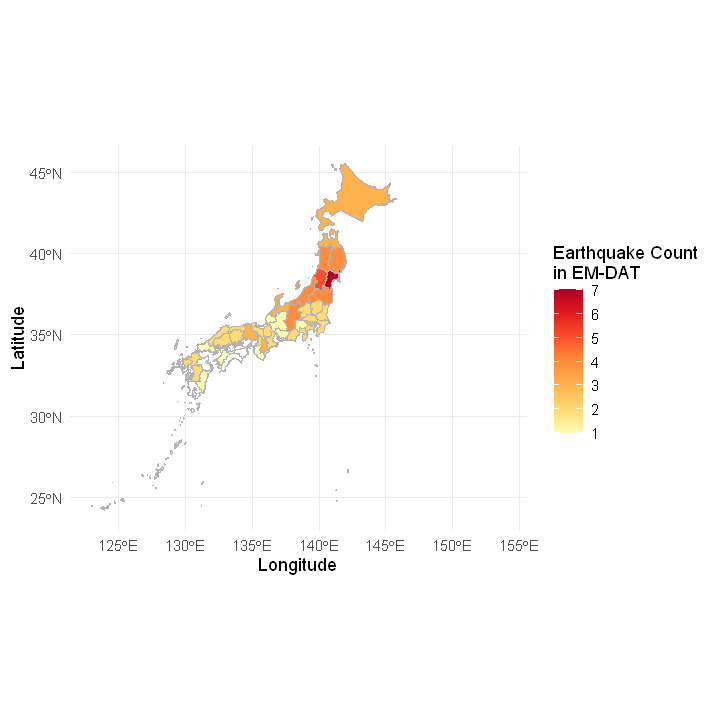

In [13]:
options(repr.plot.width = 6, repr.plot.height = 6)

ggplot(gdf_jpn_adm1_merged) +
  geom_sf(aes(fill = `EQ Count`), colour = "grey70", linewidth = 0.3) +
  scale_fill_distiller(
    palette = "YlOrRd",
    direction = 1,
    na.value = "white",
    name = "Earthquake Count\nin EM-DAT"
  ) +
  labs(x = "Longitude", y = "Latitude") +
  theme_minimal()

We have just covered the basics on how to join the EM-DAT data with an [`sf`](https://r-spatial.github.io/sf/) spatial object to make maps. To delve further into your analyses, we encourage you to continue your learning of [`sf`](https://r-spatial.github.io/sf/) and [`ggplot2`](https://ggplot2.tidyverse.org/), or, in particular, [`tmap`](https://r-tmap.github.io/tmap/) for more advanced map customization, with the many resources available online. The book [Geocomputation with R](https://r.geocompx.org/) is a good place to start.